## Vehicle Price Prediction

#### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

#### Loading Dataset

In [3]:
df = pd.read_csv('../data/vehicle_price_prediction.csv')

In [4]:
df.head()

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,exterior_color,interior_color,owner_count,accident_history,seller_type,condition,trim,vehicle_age,mileage_per_year,brand_popularity,price
0,Volkswagen,Jetta,2016,183903,173,Manual,Electric,RWD,Sedan,Blue,Brown,5,NaN,Dealer,Excellent,EX,9,20433.666667,0.040054,7208.52
1,Lexus,RX,2010,236643,352,Manual,Gasoline,FWD,Sedan,Silver,Beige,5,Minor,Dealer,Good,LX,15,15776.200000,0.039921,6911.81
2,Subaru,Crosstrek,2016,103199,188,Automatic,Diesel,AWD,Sedan,Silver,Beige,5,NaN,Dealer,Excellent,Touring,9,11466.555556,0.040230,11915.63
3,Cadillac,Lyriq,2016,118889,338,Manual,Gasoline,AWD,SUV,Black,Gray,3,NaN,Private,Good,Base,9,13209.888889,0.039847,25984.79
4,Toyota,Highlander,2018,204170,196,Manual,Diesel,FWD,Sedan,Red,Brown,5,Minor,Dealer,Excellent,Sport,7,29167.142857,0.039627,8151.30


In [5]:
df.columns

Index(['make', 'model', 'year', 'mileage', 'engine_hp', 'transmission',
       'fuel_type', 'drivetrain', 'body_type', 'exterior_color',
       'interior_color', 'owner_count', 'accident_history', 'seller_type',
       'condition', 'trim', 'vehicle_age', 'mileage_per_year',
       'brand_popularity', 'price'],
      dtype='object')

### Dataset Features – Meaning & Importance

- **make** – Brand of the vehicle; strongly affects price as luxury brands cost more.  

- **model** – Specific model name; some models hold value better than others.  

- **year** – Manufacturing year; newer cars generally have higher prices (can be converted to `vehicle_age`).  

- **mileage** – Total kilometers/miles driven; higher mileage usually lowers the price.  

- **engine_hp** – Engine horsepower; higher horsepower cars are often priced higher.  

- **transmission** – Type of gearbox (manual/automatic/CVT); automatics may be priced higher.  

- **fuel_type** – Petrol, diesel, hybrid, or electric; EVs and hybrids usually cost more.  

- **drivetrain** – FWD/RWD/AWD; AWD vehicles may have higher resale value.  

- **body_type** – Sedan, SUV, hatchback, etc.; body style impacts demand and pricing.  

- **exterior_color** – Car color; rare colors may slightly increase value.  

- **interior_color** – Interior trim color; minor effect except in luxury segments.  

- **owner_count** – Number of previous owners; single-owner cars are priced higher.  

- **accident_history** – Whether the car had accidents; accidents significantly reduce price.  

- **seller_type** – Individual, dealer, or certified pre-owned; certified cars often priced higher.  

- **condition** – Overall condition (Excellent/Good/Fair/Poor); directly affects price.  

- **trim** – Trim level (LX, EX, Sport, etc.); higher trims are more expensive.  

- **vehicle_age** – Derived from year; older vehicles usually depreciate more.  

- **mileage_per_year** – Mileage normalized by age; shows how heavily the car is used.  

- **brand_popularity** – Popularity score of brand; popular brands may retain value better.  

- **price** – Target variable (y); the final market price we are predicting.  

In [6]:
df.shape

(1000000, 20)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   make              1000000 non-null  object 
 1   model             1000000 non-null  object 
 2   year              1000000 non-null  int64  
 3   mileage           1000000 non-null  int64  
 4   engine_hp         1000000 non-null  int64  
 5   transmission      1000000 non-null  object 
 6   fuel_type         1000000 non-null  object 
 7   drivetrain        1000000 non-null  object 
 8   body_type         1000000 non-null  object 
 9   exterior_color    1000000 non-null  object 
 10  interior_color    1000000 non-null  object 
 11  owner_count       1000000 non-null  int64  
 12  accident_history  249867 non-null   object 
 13  seller_type       1000000 non-null  object 
 14  condition         1000000 non-null  object 
 15  trim              1000000 non-null  object 
 16  v

In [8]:
df.isnull().sum()

make                     0
model                    0
year                     0
mileage                  0
engine_hp                0
transmission             0
fuel_type                0
drivetrain               0
body_type                0
exterior_color           0
interior_color           0
owner_count              0
accident_history    750133
seller_type              0
condition                0
trim                     0
vehicle_age              0
mileage_per_year         0
brand_popularity         0
price                    0
dtype: int64

- accident_history is 75% null but dropping it don't makes sense as it plays a vital role in prediction.
- Will consider 'no accident' for all the nulls.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,1000000.0,2017.453816,3.902285,2000.000000,2015.000000,2018.000000,2020.000000,2025.000000
mileage,1000000.0,112660.126464,72088.236925,500.000000,57654.000000,103331.000000,157865.000000,300000.000000
engine_hp,1000000.0,235.664301,93.614773,90.000000,162.000000,215.000000,300.000000,581.000000
owner_count,1000000.0,3.477846,1.544856,1.000000,2.000000,4.000000,5.000000,5.000000
vehicle_age,1000000.0,7.585987,3.829534,1.000000,5.000000,7.000000,10.000000,25.000000
mileage_per_year,1000000.0,14540.674200,6108.901522,33.333333,10487.633523,14688.118056,18685.942308,55391.000000
brand_popularity,1000000.0,0.040001,0.000234,0.039318,0.039842,0.040022,0.040148,0.040484
price,1000000.0,20329.302593,13644.467189,1500.000000,10324.527500,17864.740000,27601.402500,93422.090000


In [10]:
df.dtypes

make                 object
model                object
year                  int64
mileage               int64
engine_hp             int64
transmission         object
fuel_type            object
drivetrain           object
body_type            object
exterior_color       object
interior_color       object
owner_count           int64
accident_history     object
seller_type          object
condition            object
trim                 object
vehicle_age           int64
mileage_per_year    float64
brand_popularity    float64
price               float64
dtype: object

In [35]:
df.nunique()

make                         25
model                       105
mileage                  257043
engine_hp                   478
transmission                  2
fuel_type                     3
drivetrain                    3
body_type                     7
exterior_color                6
interior_color                4
owner_count                   5
accident_history              3
seller_type                   2
condition                     3
trim                          6
vehicle_age                  25
mileage_per_year         522677
brand_popularity             24
price                    850936
price_zscore             850936
price_log                850936
mileage_per_year_calc    522677
dtype: int64

#### Understanding the distribution of categorical features

In [11]:
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
cat_features

['make',
 'model',
 'transmission',
 'fuel_type',
 'drivetrain',
 'body_type',
 'exterior_color',
 'interior_color',
 'accident_history',
 'seller_type',
 'condition',
 'trim']

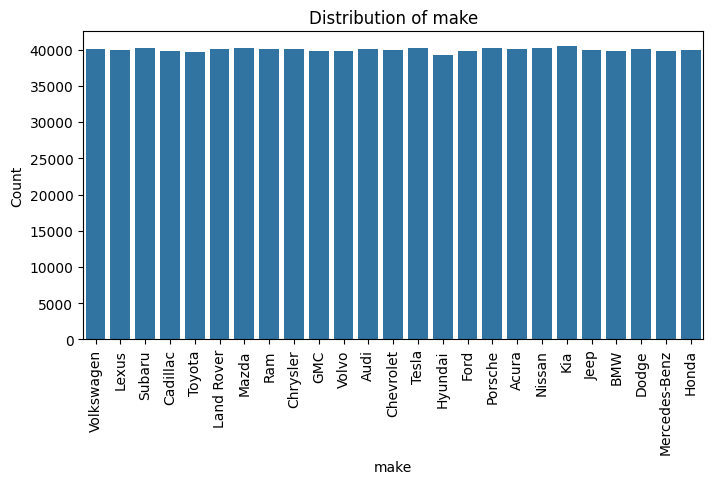

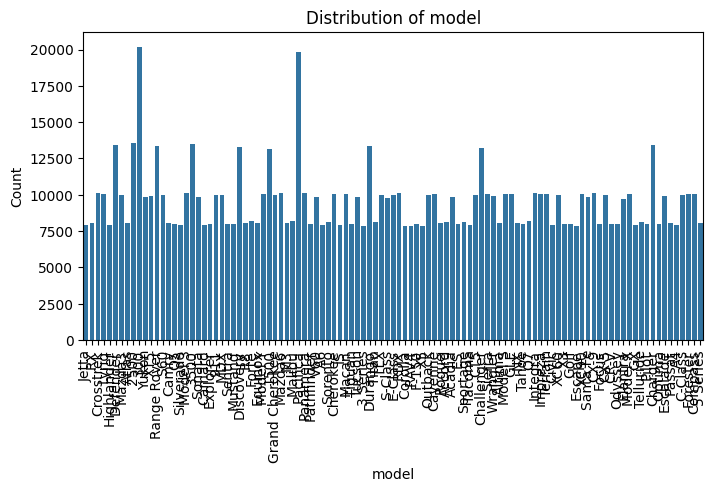

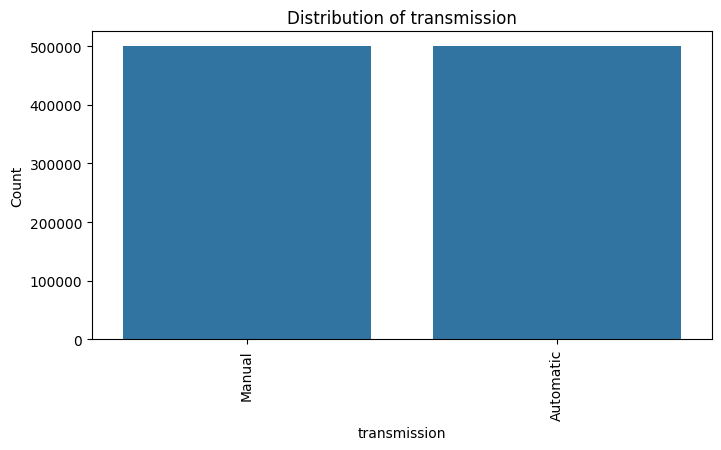

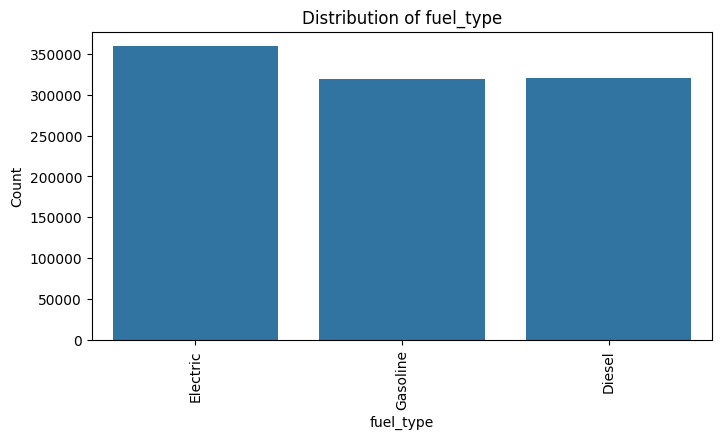

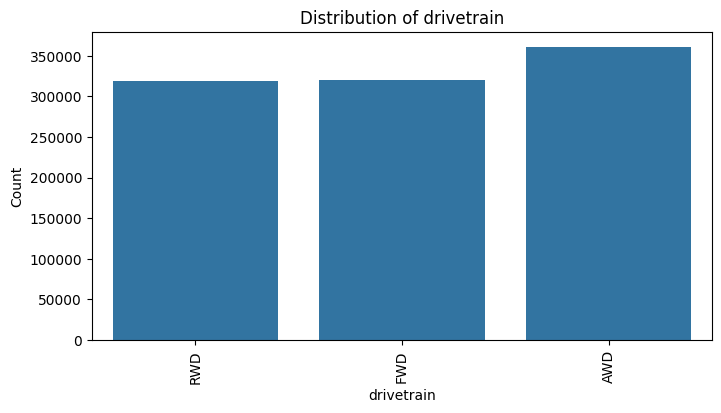

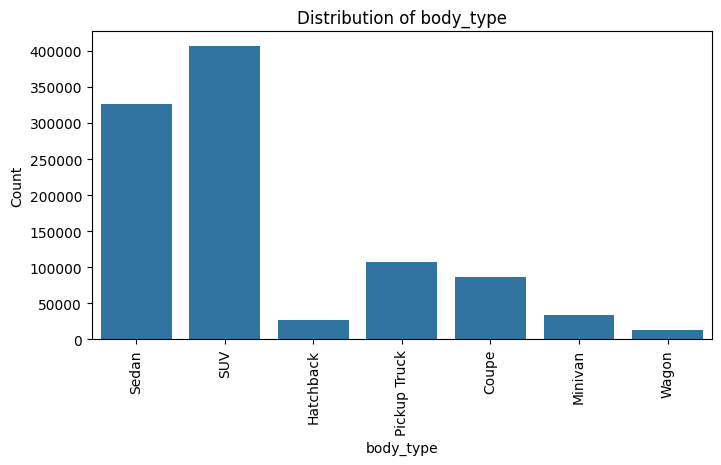

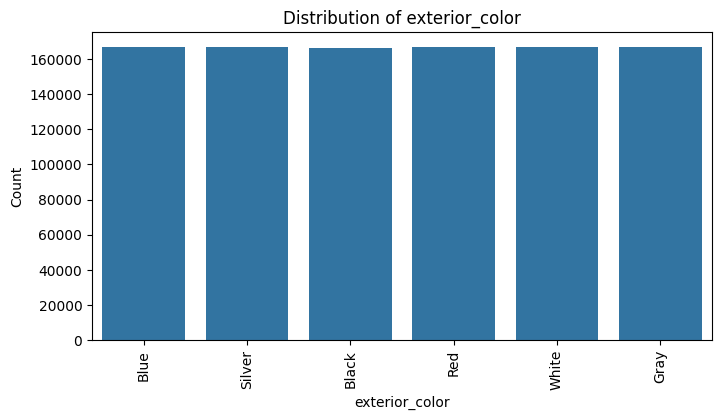

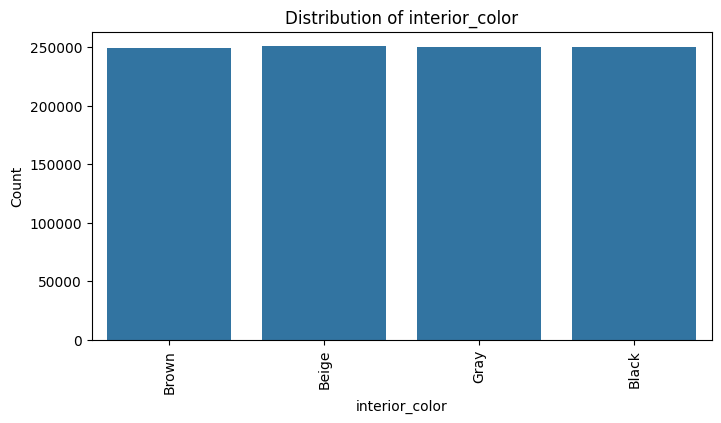

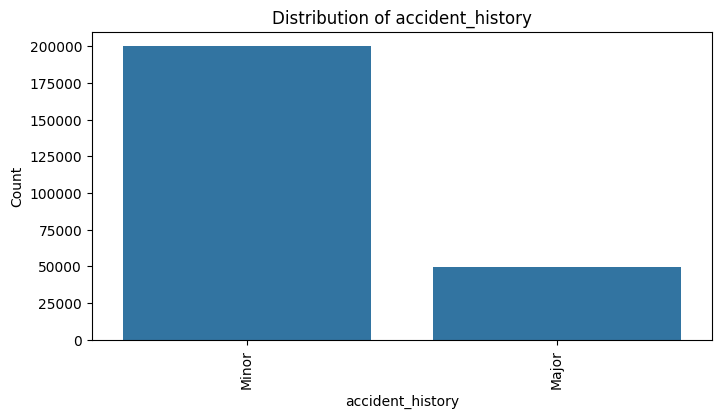

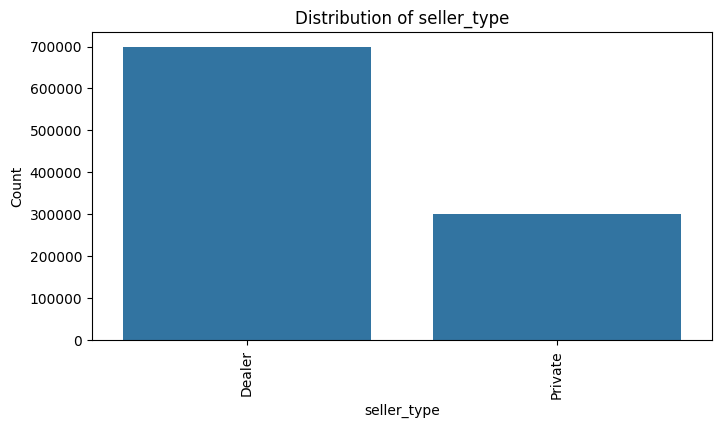

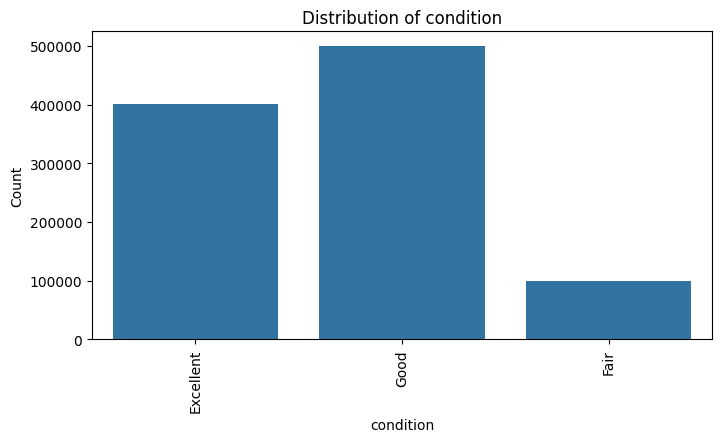

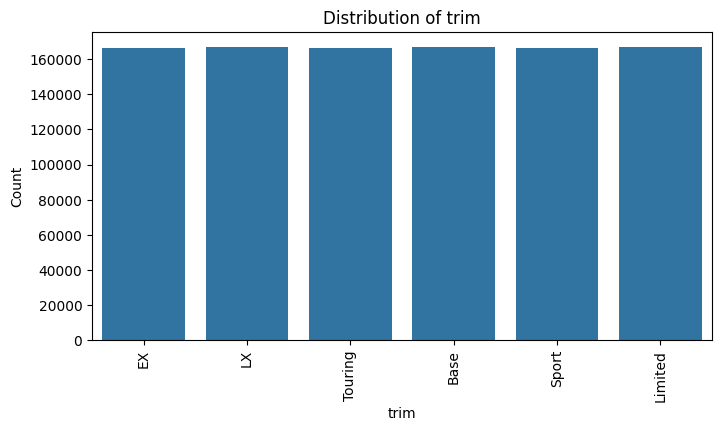

In [12]:
for feature in cat_features:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=feature)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.show()

In [13]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
num_features

['year',
 'mileage',
 'engine_hp',
 'owner_count',
 'vehicle_age',
 'mileage_per_year',
 'brand_popularity',
 'price']

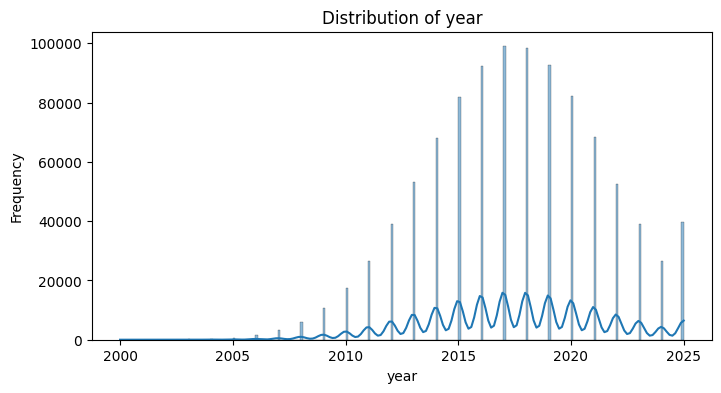

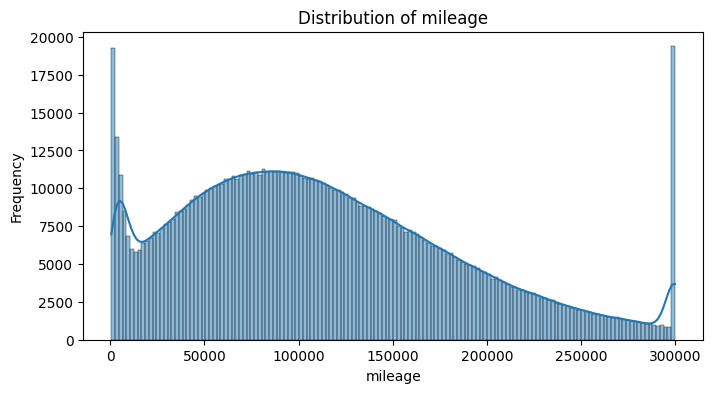

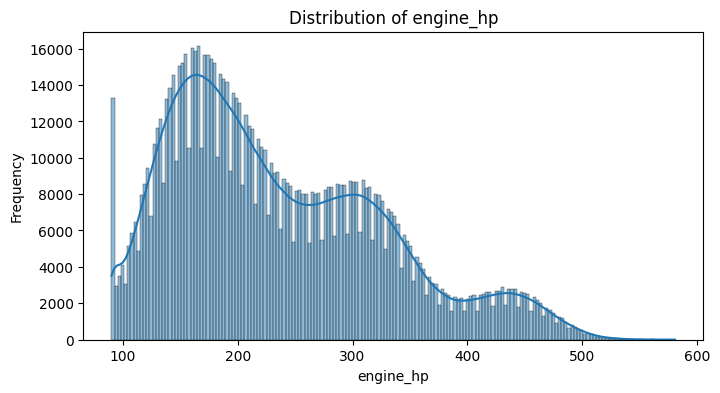

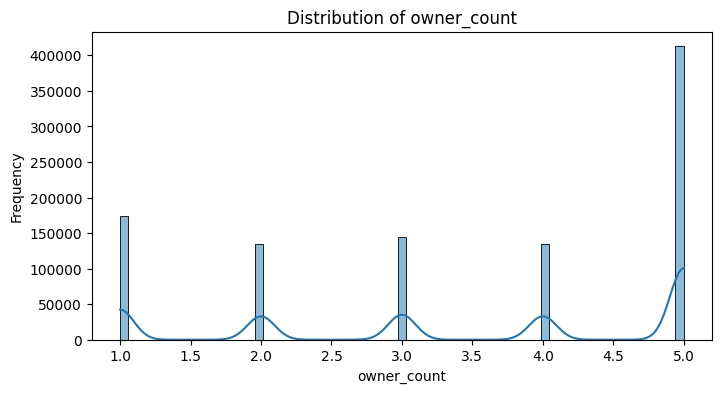

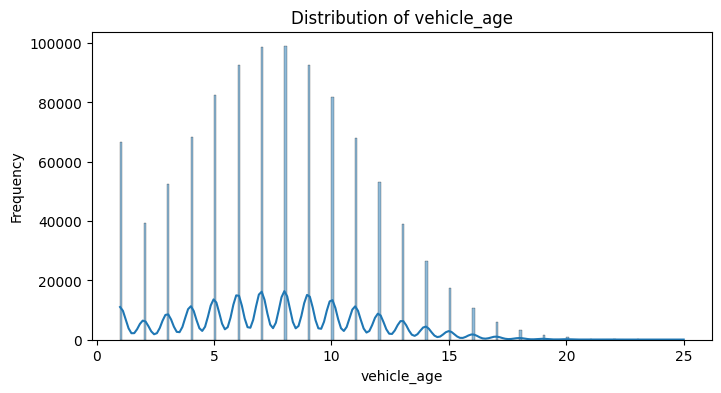

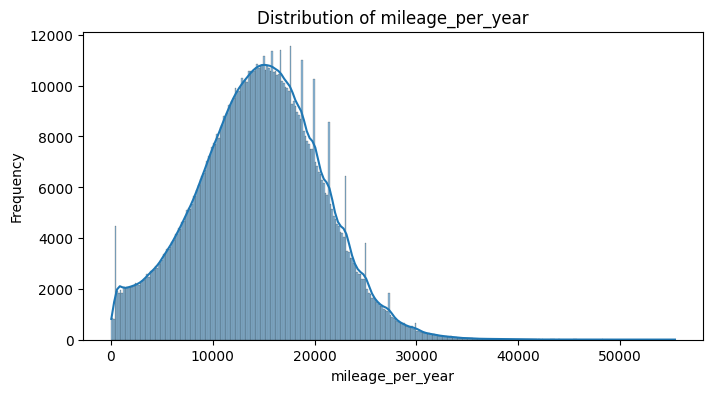

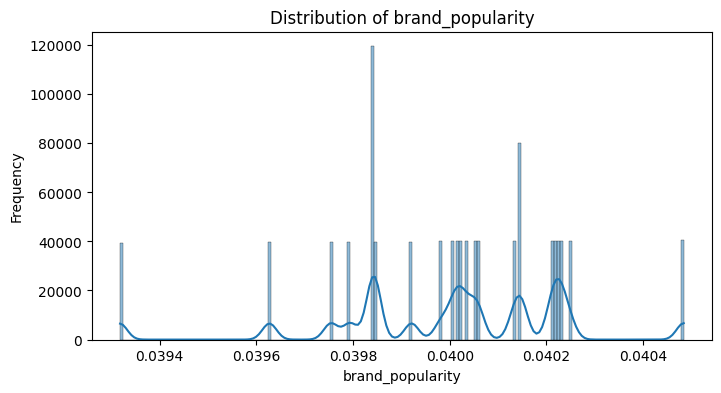

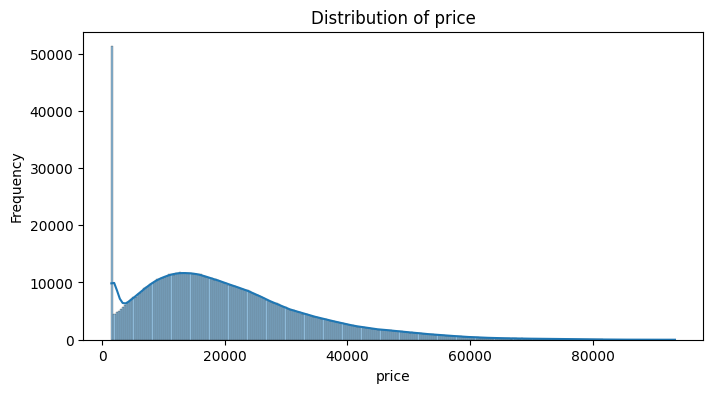

In [14]:
for feature in num_features:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=feature, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

- vehicle age and year are showing same trend

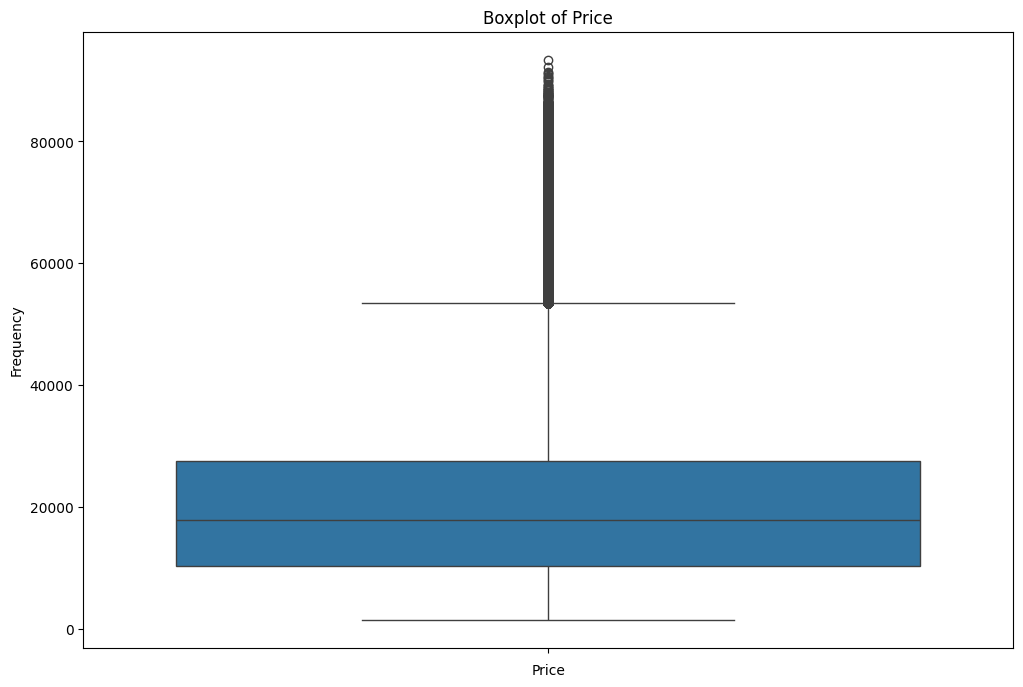

In [15]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df['price'])
plt.title("Boxplot of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

- highly skewed data

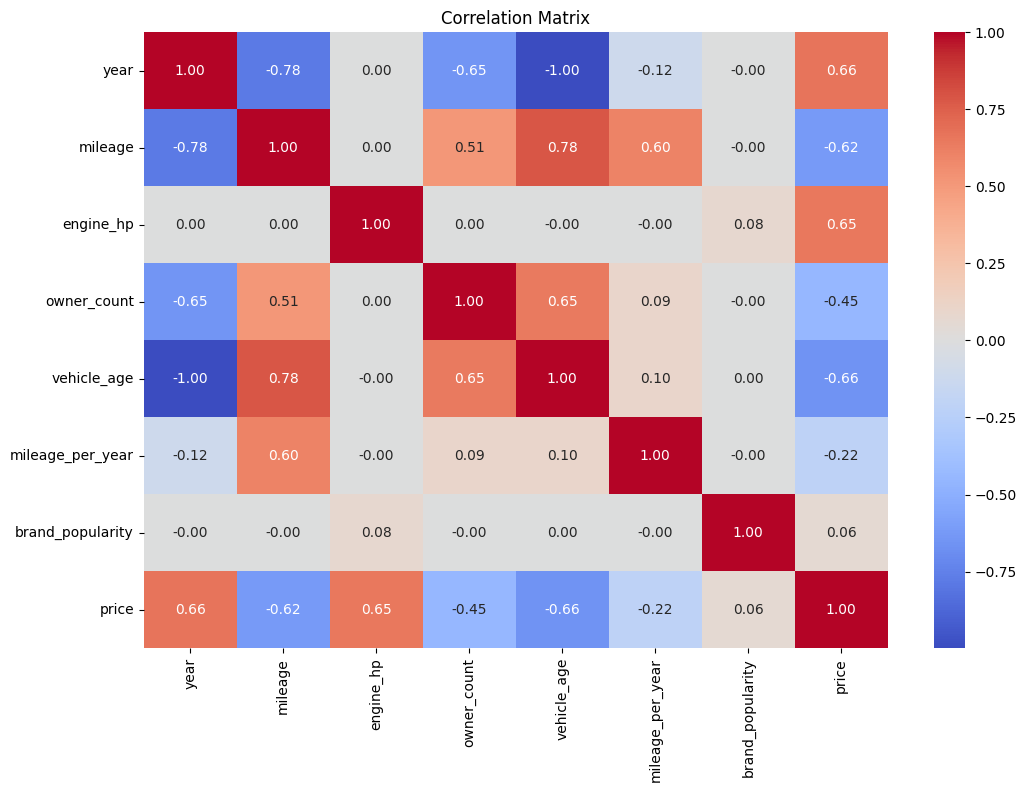

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_features].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- Only `year` is highly co-related so we gonna drop it 

In [17]:
df.drop(columns=['year'], inplace=True)

In [18]:
df['accident_history'] = df['accident_history'].fillna("No Accident")

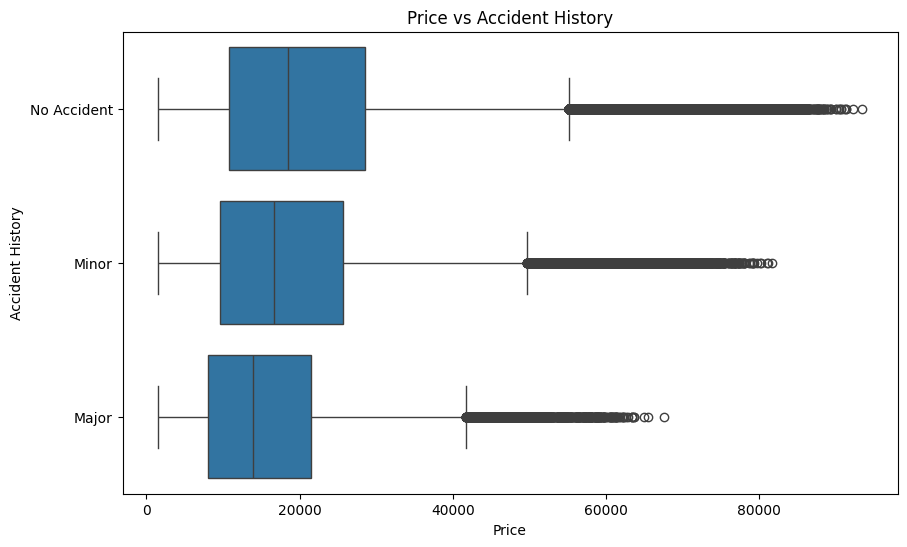

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='price', y='accident_history')
plt.title("Price vs Accident History")
plt.xlabel("Price")
plt.ylabel("Accident History")
plt.show()

In [20]:
from scipy.stats import zscore

df['price_zscore'] = zscore(df['price'])
outliers = df[np.abs(df['price_zscore']) > 3]  # beyond 3 std devs
print(f"Outliers found: {len(outliers)}")

Outliers found: 10861


- will drop this outliers 

In [21]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Outliers found: {len(outliers)}")

Outliers found: 25524


- Outliers detected in Price column: 10,861 (~1%) of records.

- Boxplot shows these are likely genuine high-priced vehicles, not errors.

- Decision: Keep outliers, as they hold valuable information.

- Apply log transformation to normalize skewed price distribution.

In [22]:
df['price_log'] = np.log1p(df['price']) # log(1 + x) to handle zero values

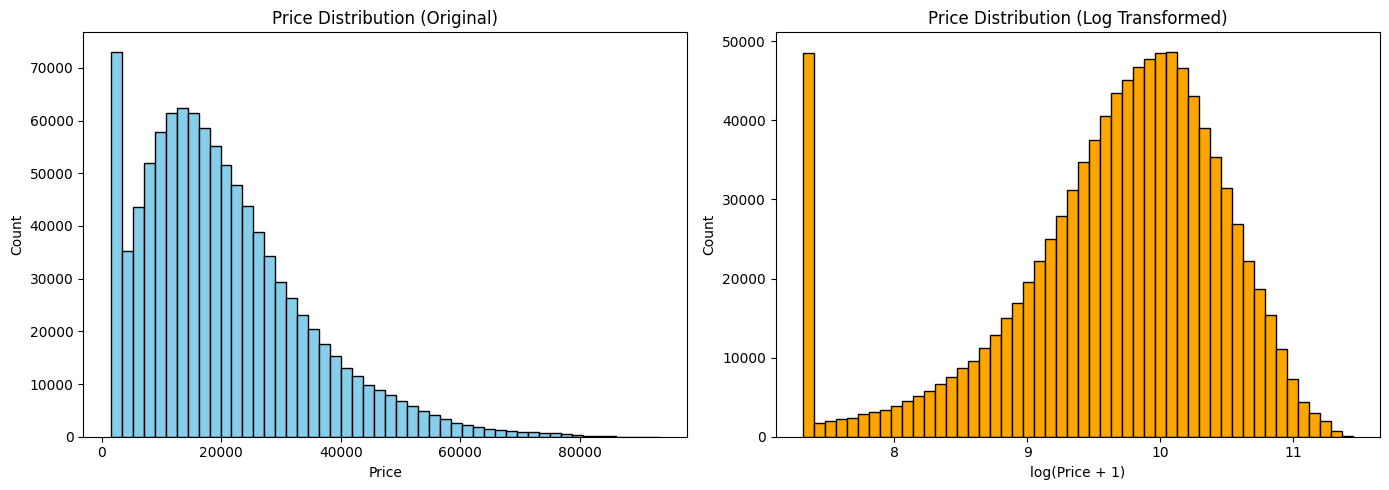

In [23]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title("Price Distribution (Original)")
plt.xlabel("Price")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(df['price_log'], bins=50, color='orange', edgecolor='black')
plt.title("Price Distribution (Log Transformed)")
plt.xlabel("log(Price + 1)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### Price vs Numerical Features

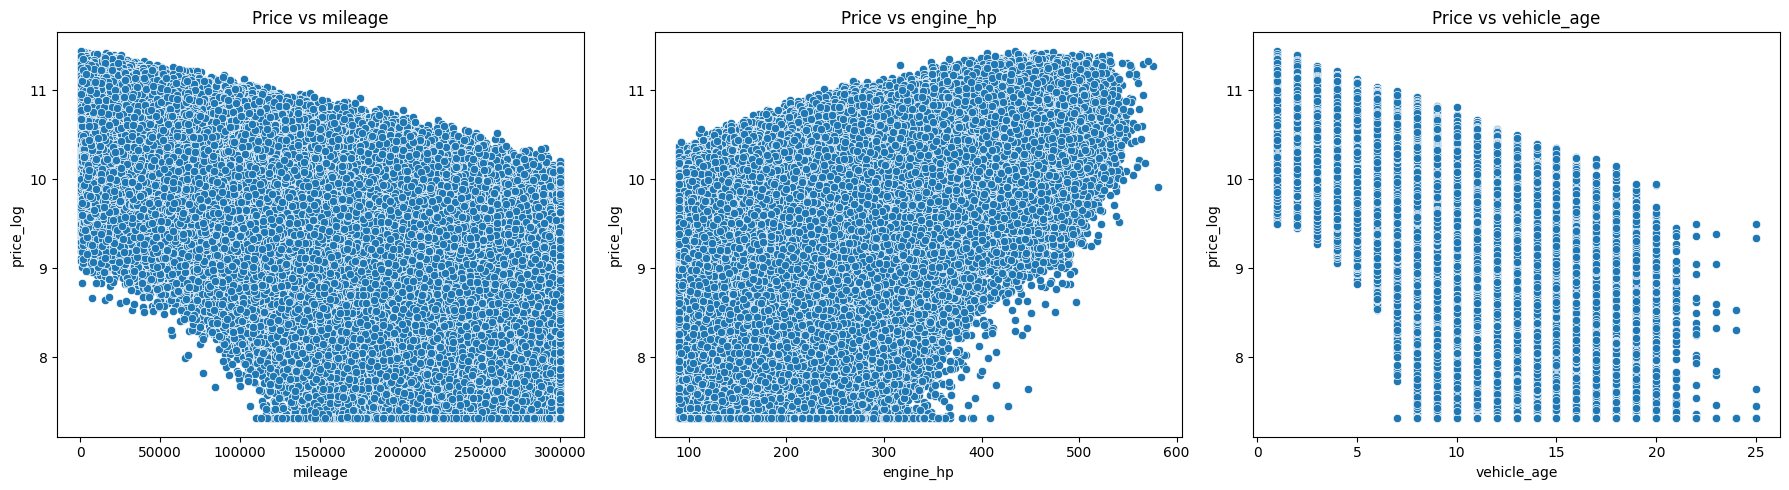

In [24]:
columns = ['mileage', 'engine_hp', 'vehicle_age']

plt.figure(figsize=(18, 5))

for i, col in enumerate(columns):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=df[col], y=df['price_log'], data=df)
    plt.title(f'Price vs {col}')
    plt.xlabel(col)
    plt.ylabel('price_log')

plt.tight_layout()
plt.show()

#### Price vs Categorical features

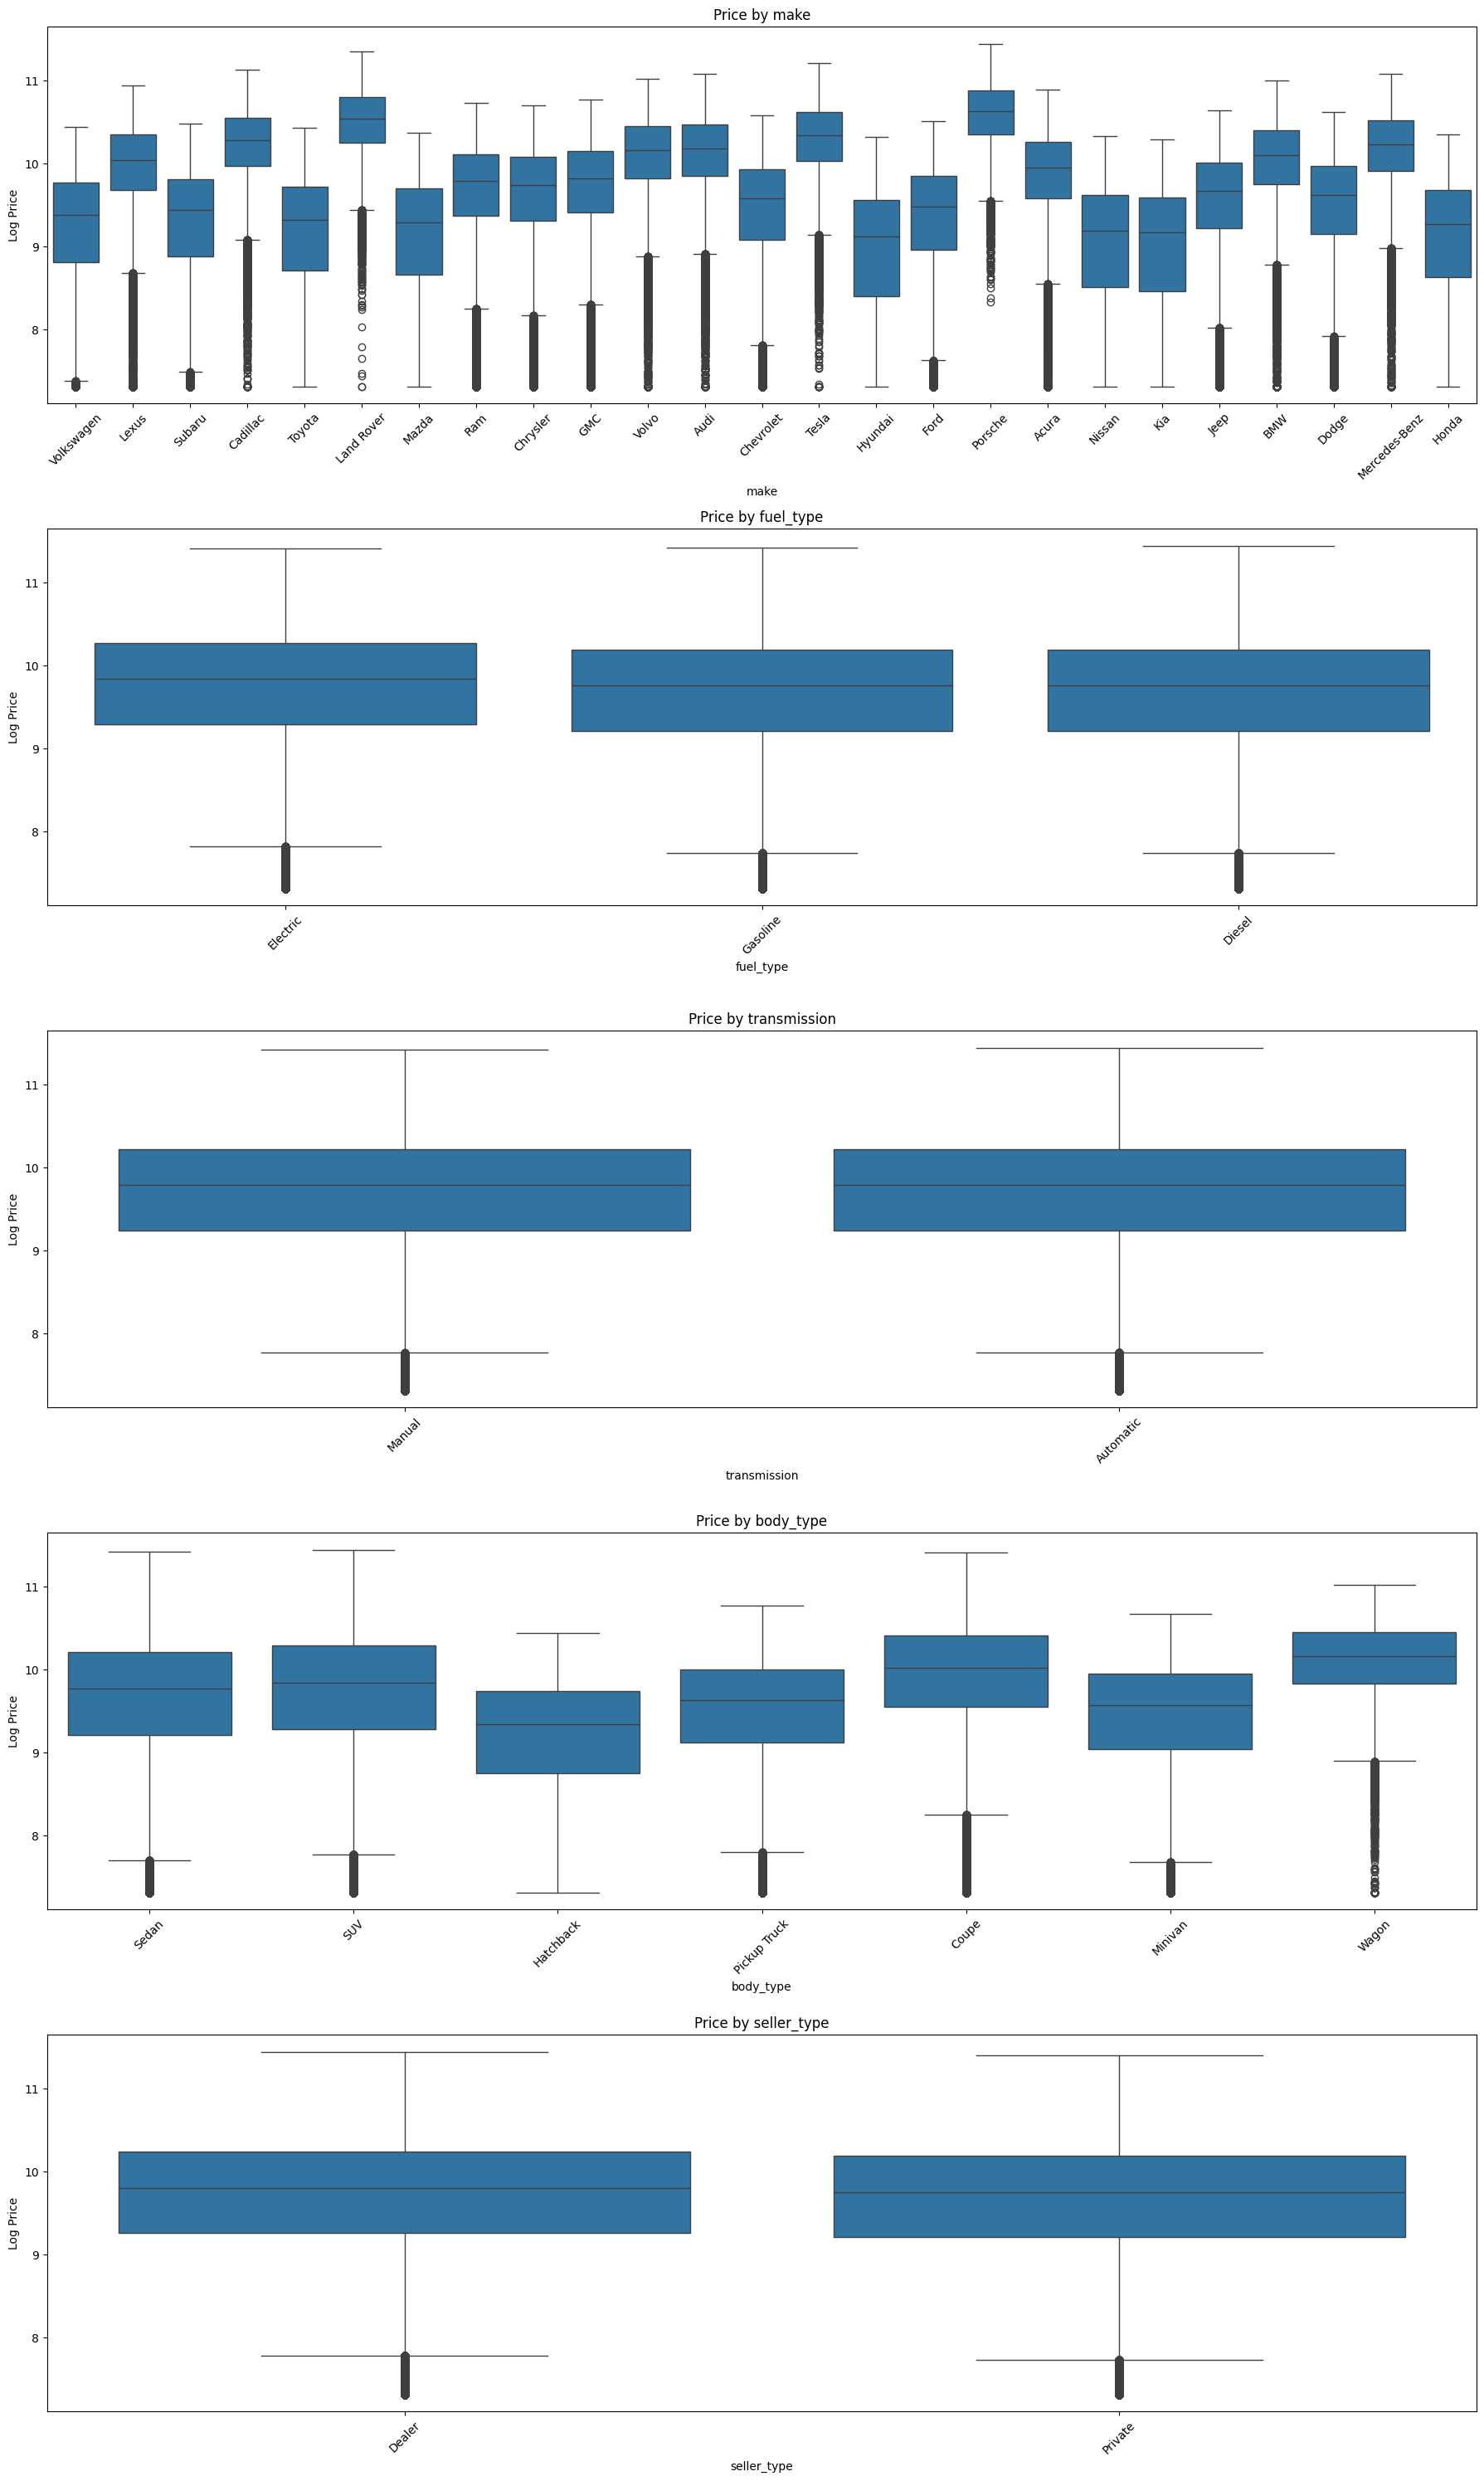

In [ ]:
cat_features = ['make', 'fuel_type', 'transmission', 'body_type', 'seller_type']

plt.figure(figsize=(18, 30))

for idx, feature in enumerate(cat_features):
    plt.subplot(len(cat_features), 1, idx+1)
    sns.boxplot(data=df, x=feature, y='price_log')  
    plt.title(f'Price by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Log Price')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- These trends highlight how brand, fuel type, transmission, body style, and seller type significantly influence vehicle pricing.



#### which brands have more reported accidents.

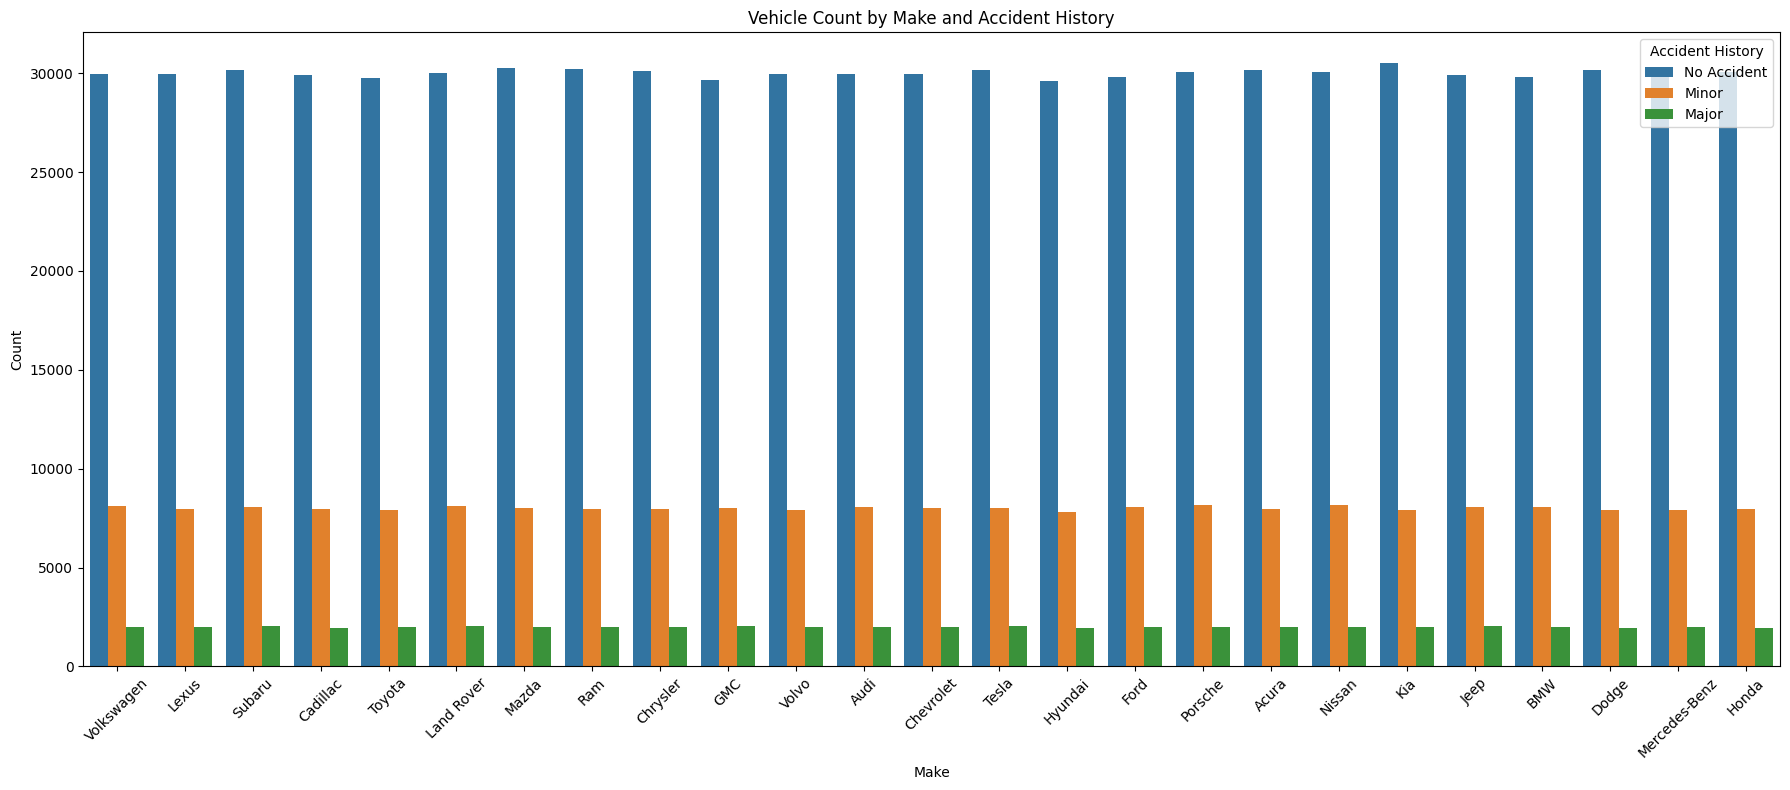

In [27]:
plt.figure(figsize=(18, 8))
sns.countplot(data=df, x='make', hue='accident_history')
plt.title('Vehicle Count by Make and Accident History')
plt.xlabel('Make')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Accident History')
plt.tight_layout()
plt.show()

- all the comapny cars have same accident rate 

#### Analyze which fuel type is common in which body type.

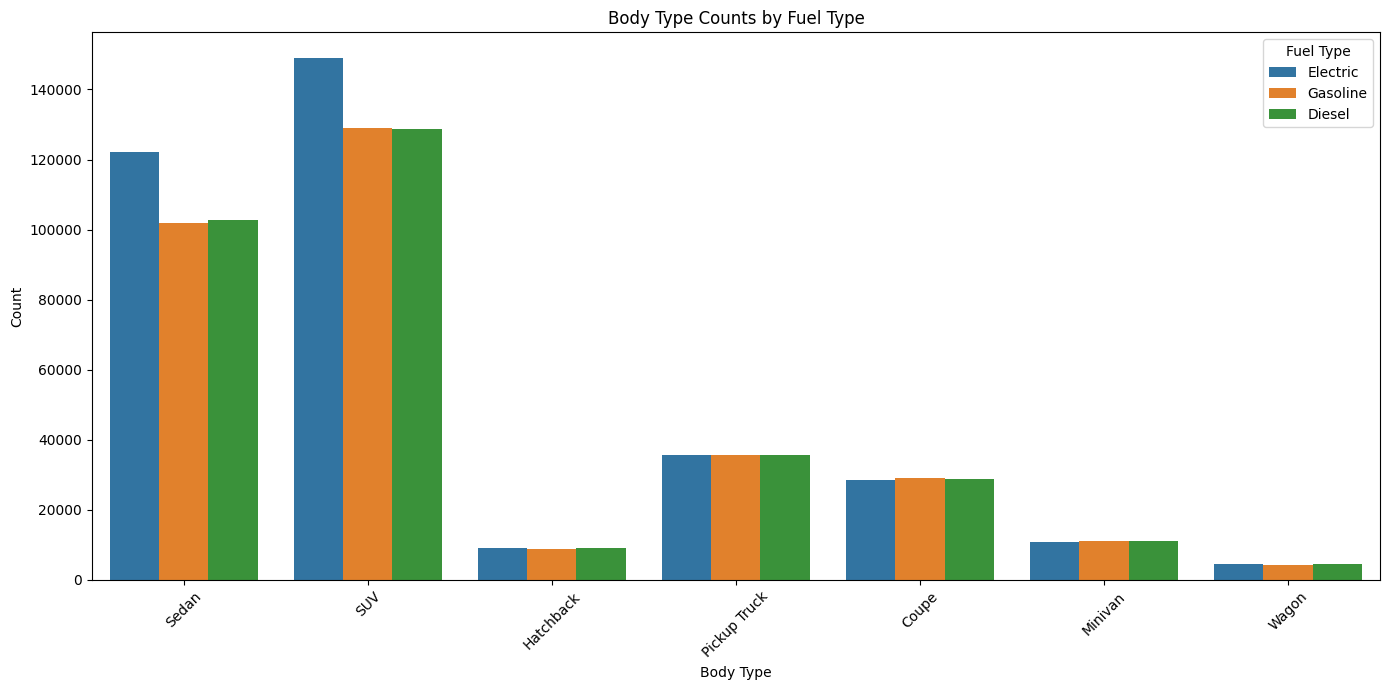

In [28]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='body_type', hue='fuel_type')
plt.title('Body Type Counts by Fuel Type')
plt.xlabel('Body Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Fuel Type')
plt.tight_layout()
plt.show()

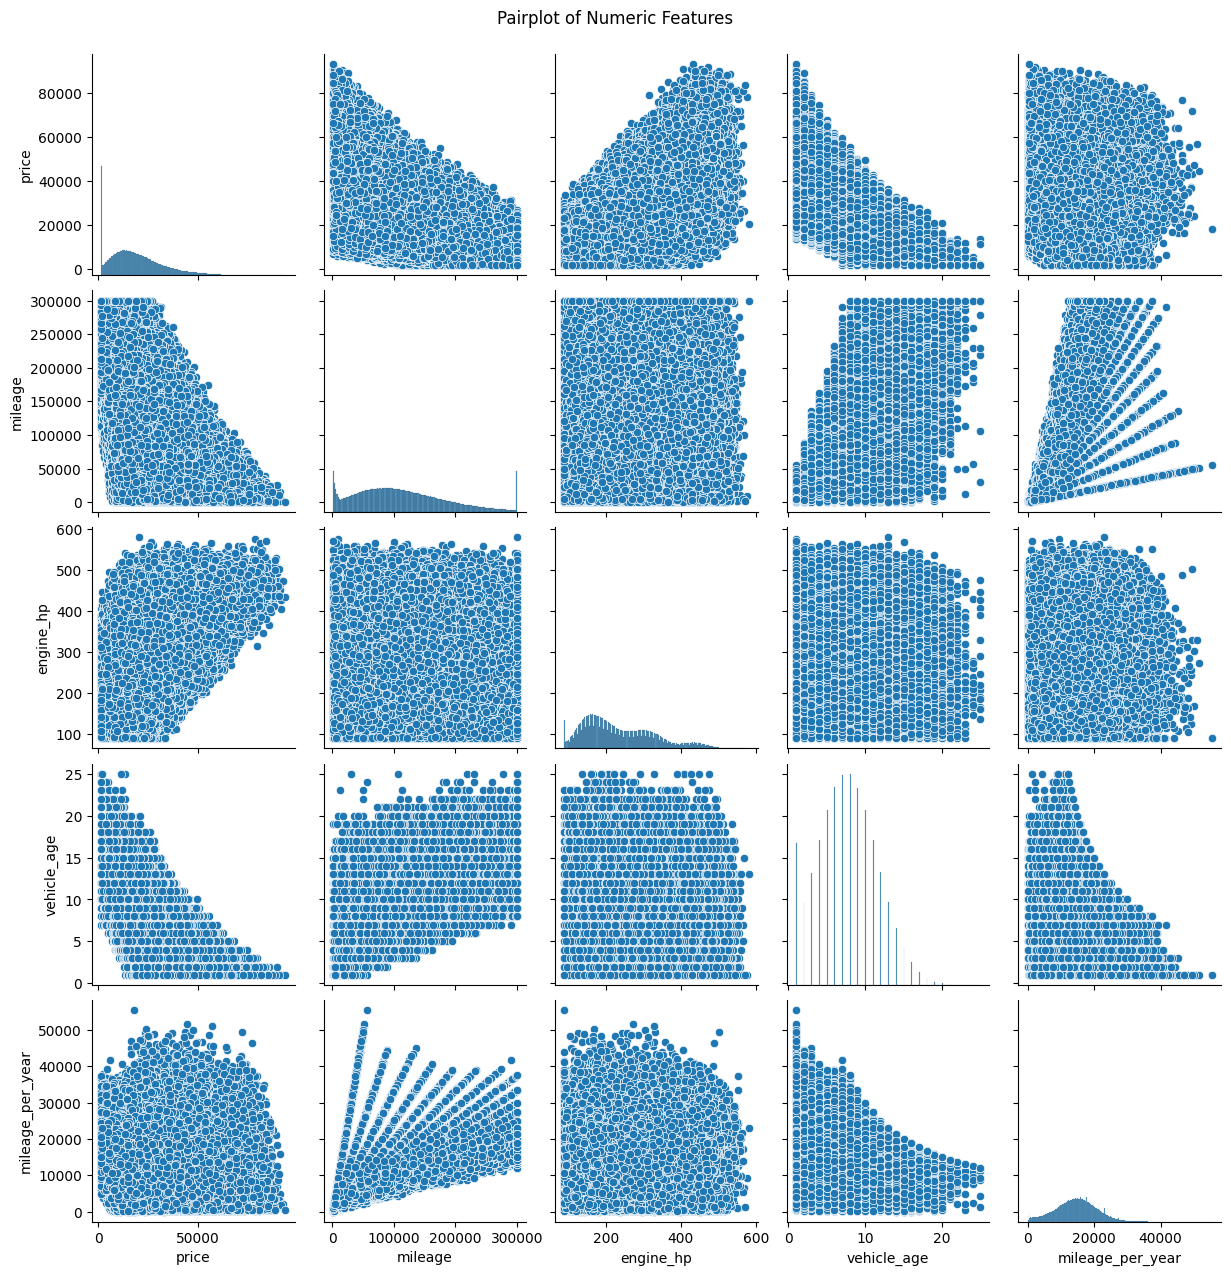

In [31]:
numeric_features = ['price', 'mileage', 'engine_hp', 'vehicle_age', 'mileage_per_year']

sns.pairplot(df[numeric_features])
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()

- Price vs Mileage/Vehicle Age: There is a clear negative correlation; older vehicles and those with higher mileage tend to have lower prices.

- Price vs Engine HP: Vehicles with higher engine horsepower generally have higher prices, showing a positive relationship.

- Mileage vs Vehicle Age: As expected, older vehicles accumulate more mileage.

- Mileage per Year: Most vehicles cluster at lower mileage per year, but some outliers exist.

- Distributions: Price is highly skewed, while mileage and vehicle age show more spread.

- Relationships: The strongest relationships are price with mileage and vehicle age, confirming these are key predictors for vehicle price.

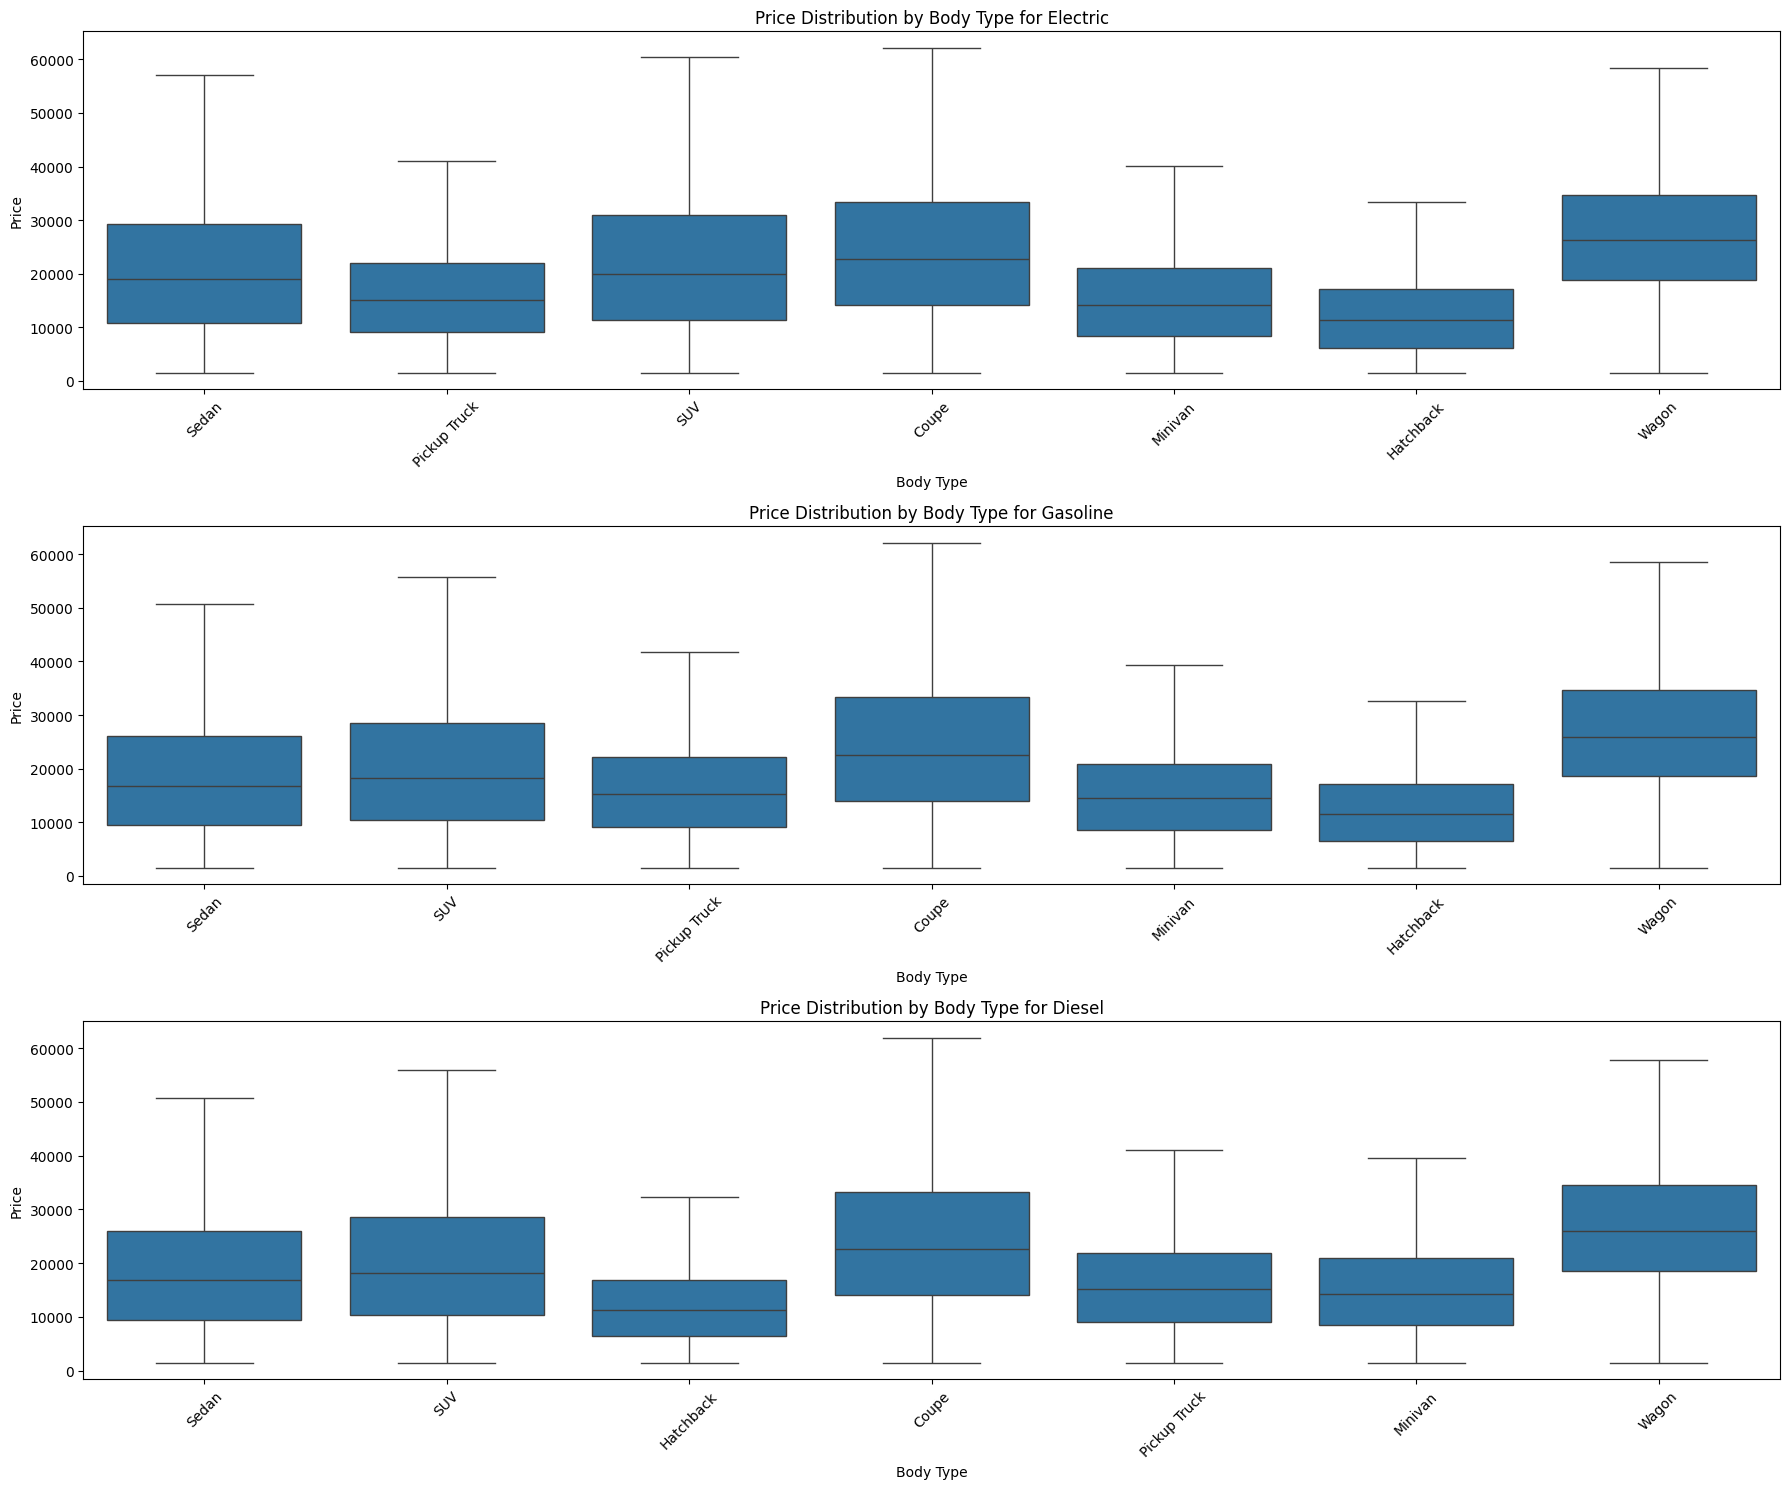

In [33]:
fuel_types = df['fuel_type'].unique()
plt.figure(figsize=(18, 5 * len(fuel_types)))

for i, fuel in enumerate(fuel_types):
    plt.subplot(len(fuel_types), 1, i+1)
    sns.boxplot(data=df[df['fuel_type'] == fuel], x='body_type', y='price', showfliers=False)
    plt.title(f'Price Distribution by Body Type for {fuel}')
    plt.xlabel('Body Type')
    plt.ylabel('Price')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- ody type significantly affects price within each fuel type. 

- SUVs, Coupes, and Wagons command higher prices, while Hatchbacks and Minivans are more affordable. 

- Electric vehicles are generally priced higher across body types.

In [34]:
# Check if mileage_per_year is directly derived from mileage and vehicle_age
df['mileage_per_year_calc'] = df['mileage'] / df['vehicle_age'].replace(0, np.nan)
comparison = np.isclose(df['mileage_per_year'], df['mileage_per_year_calc'], equal_nan=True)
print(f"Rows where mileage_per_year matches calculation: {comparison.sum()} / {len(df)}")
print(f"All values match: {comparison.all()}")

Rows where mileage_per_year matches calculation: 1000000 / 1000000
All values match: True


- it is directly derived so we will drop this columns